In [68]:
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import whisper
import torch
from torch import Tensor
from torch import nn

In [69]:
model = whisper.load_model("tiny")

In [70]:
# load audio and pad/trim it to fit 30 seconds
audio = whisper.load_audio("the_big_short.mp3")
print(type(audio))
print(audio.shape)
# <class 'numpy.ndarray'>
# (1857792,)

audio = whisper.pad_or_trim(audio)
print(type(audio))
print(audio.shape)
# <class 'numpy.ndarray'>
# (480000,)

<class 'numpy.ndarray'>
(1857792,)
<class 'numpy.ndarray'>
(480000,)


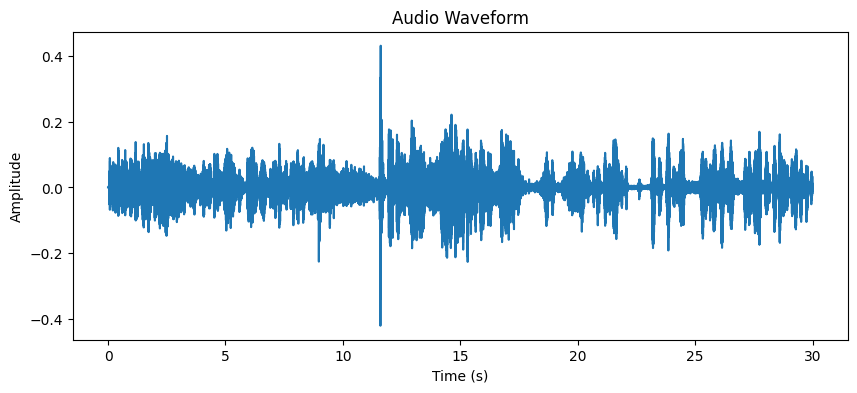

In [71]:
# Plot the audio waveform
plt.figure(figsize=(10, 4))
plt.plot(np.linspace(0, len(audio) / 16000, num=len(audio)), audio)
plt.title("Audio Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

In [72]:
# make log-Mel spectrogram and move to the same device as the model
mel = whisper.log_mel_spectrogram(audio).to(model.device)
print(mel.shape)
# torch.Size([80, 3000])

torch.Size([80, 3000])


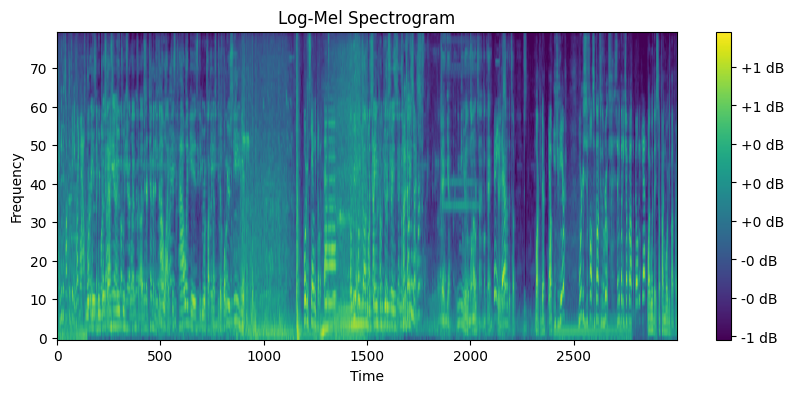

In [73]:
# Plot the log-Mel spectrogram
mel_np = mel.cpu().detach().numpy()
plt.figure(figsize=(10, 4))
plt.imshow(mel_np, aspect="auto", origin="lower")
plt.title("Log-Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar(format="%+2.0f dB")
plt.show()

In [74]:
# detect the spoken language
_, probs = model.detect_language(mel)
print(f"Detected language: {max(probs, key=probs.get)}")

# decode the audio
options = whisper.DecodingOptions()

print(type(options))
print(options)

Detected language: en
<class 'whisper.decoding.DecodingOptions'>
DecodingOptions(task='transcribe', language=None, temperature=0.0, sample_len=None, best_of=None, beam_size=None, patience=None, length_penalty=None, prompt=None, prefix=None, suppress_tokens='-1', suppress_blank=True, without_timestamps=False, max_initial_timestamp=1.0, fp16=True)


In [75]:
dims = {
    "n_mels": 80,
    "n_vocab": 51865,
    "n_audio_ctx": 1500,
    "n_audio_state": 384,
    "n_audio_head": 6,
    "n_audio_layer": 4,
    "n_text_ctx": 448,
    "n_text_state": 384,
    "n_text_head": 6,
    "n_text_layer": 4,
}

In [76]:
class Conv1d(nn.Conv1d):
    def _conv_forward(
        self, x: Tensor, weight: Tensor, bias: Optional[Tensor]
    ) -> Tensor:
        return super()._conv_forward(
            x, weight.to(x.dtype), None if bias is None else bias.to(x.dtype)
        )

In [85]:
# https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html#conv1d

conv1 = Conv1d(
    in_channels=dims["n_mels"],
    out_channels=dims["n_audio_state"],
    kernel_size=3,
    padding=1,
)

In [86]:
conv1

Conv1d(80, 384, kernel_size=(3,), stride=(1,), padding=(1,))

In [87]:
mel.shape

torch.Size([80, 3000])

In [88]:
res = conv1(mel)

In [89]:
res.shape

torch.Size([384, 3000])

In [50]:
def get_audio_features(mel: Tensor, model):
    mel = mel.unsqueeze(0)
    mel = mel.half()
    audio_features = model.encoder(mel)
    return audio_features

In [51]:
audio_features: Tensor = get_audio_features(mel, model)

In [53]:
audio_features.shape

torch.Size([1, 1500, 384])

In [ ]:
result = whisper.decode(model, mel, options)

# print the recognized text
print(result.text)